In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('heart_disease_uci.csv')

In [3]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [5]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


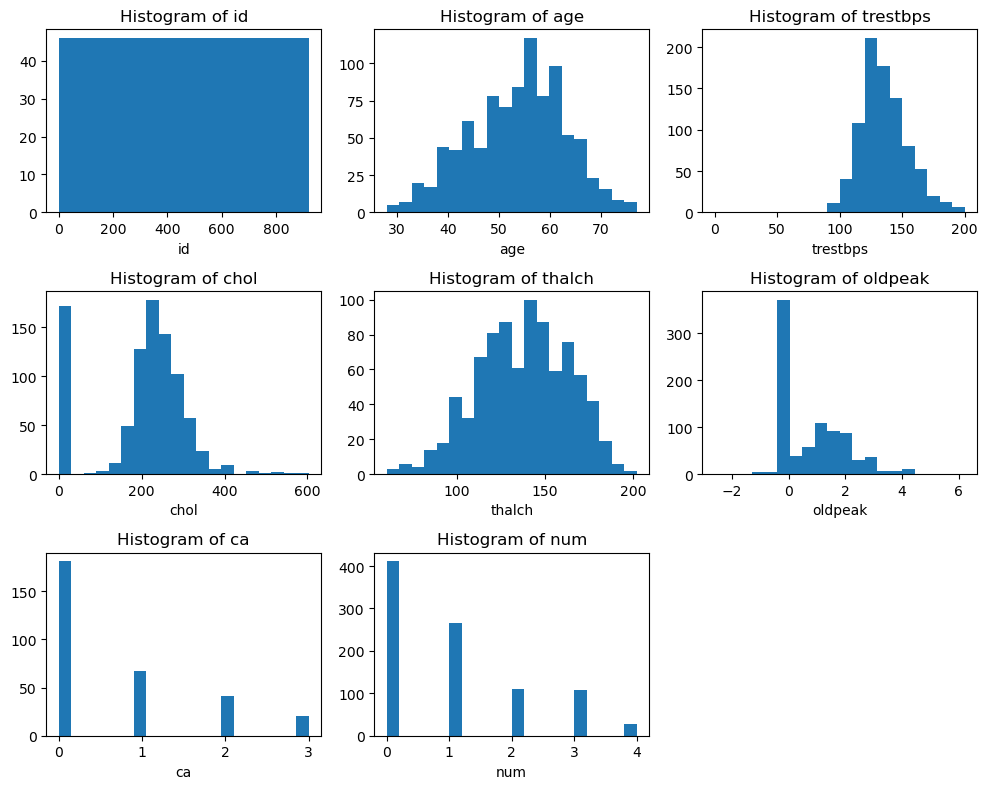

In [6]:
import matplotlib.pyplot as plt

numeric_vars = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,8))

for i, var in enumerate(numeric_vars):
    plt.subplot(3,3,i+1)
    plt.hist(df[var].dropna(), bins=20)
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)

plt.tight_layout()
plt.show()

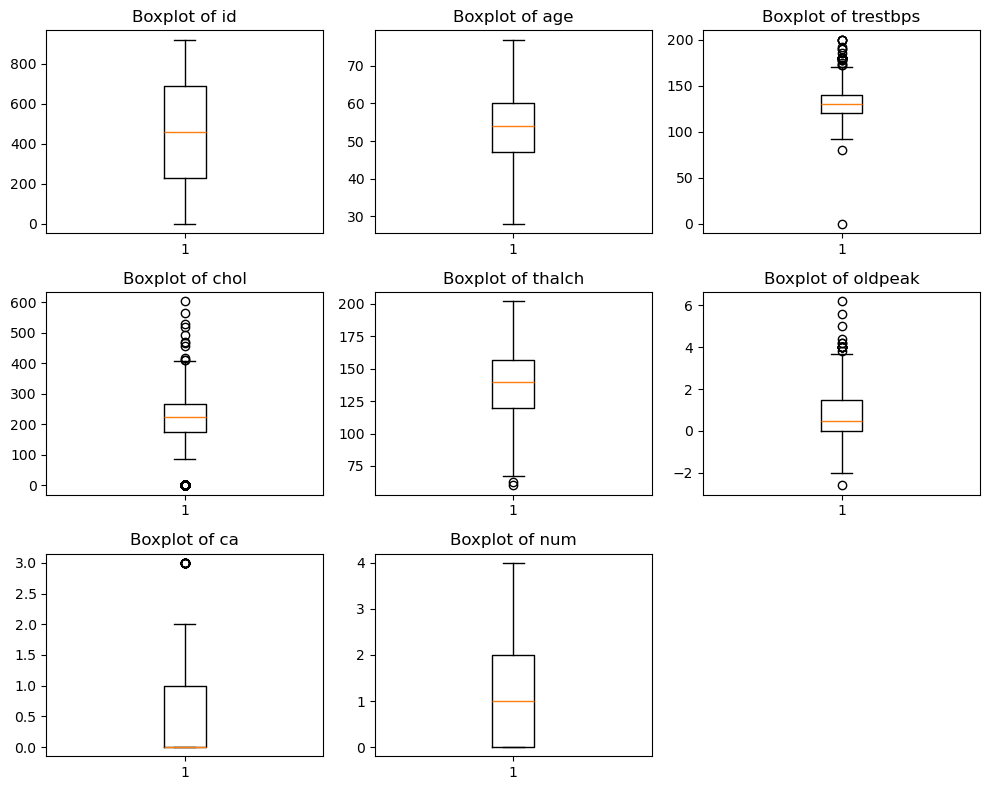

In [7]:
plt.figure(figsize=(10,8))

for i, var in enumerate(numeric_vars):
    plt.subplot(3,3,i+1)
    plt.boxplot(df[var].dropna())
    plt.title(f"Boxplot of {var}")

plt.tight_layout()
plt.show()

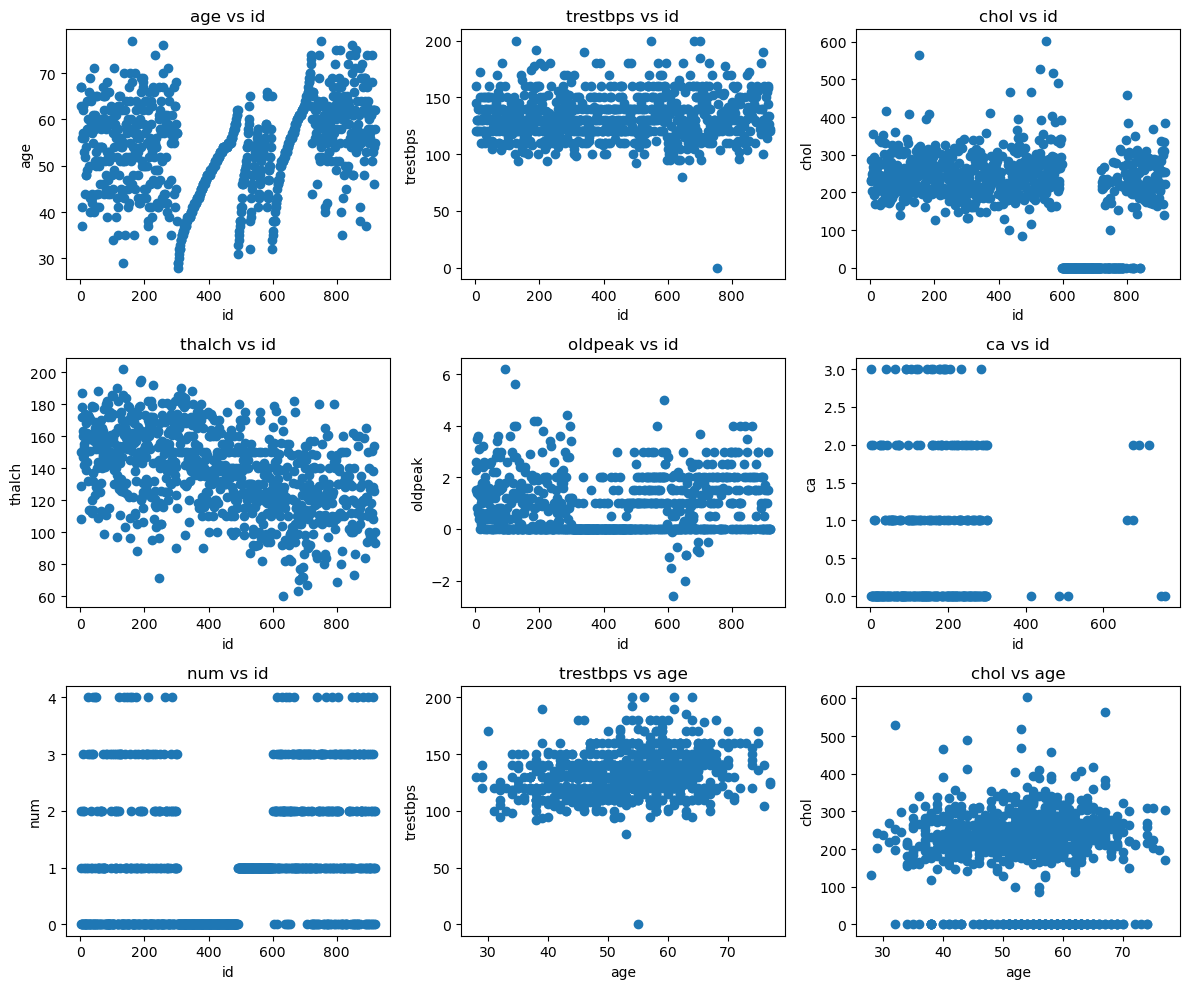

In [8]:
numeric_vars = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,10))

plot_count = 1

for i in range(len(numeric_vars)-1):
    for j in range(i+1,len(numeric_vars)):

        if plot_count > 9:
            break

        plt.subplot(3,3,plot_count)
        plt.scatter(df[numeric_vars[i]], df[numeric_vars[j]])
        plt.xlabel(numeric_vars[i])
        plt.ylabel(numeric_vars[j])
        plt.title(f"{numeric_vars[j]} vs {numeric_vars[i]}")

        plot_count += 1

plt.tight_layout()
plt.show()

In [9]:
# Count missing values
print(df.isna().sum())

# Percentage of missing values
missing_perc = df.isna().mean() * 100
missing_perc

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

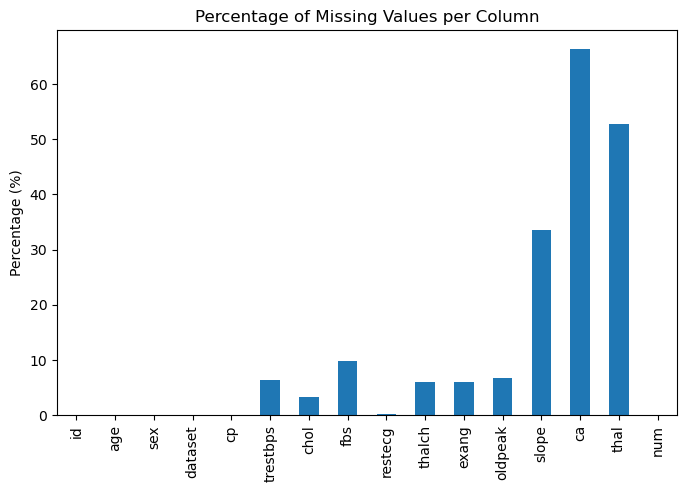

In [10]:
missing_perc.plot(kind='bar', figsize=(8,5))
plt.title("Percentage of Missing Values per Column")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90)
plt.show()

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
def get_mode(series):
    return series.mode()[0]
cat_cols = df.select_dtypes(include=['object','category']).columns

for col in cat_cols:
    df[col].fillna(get_mode(df[col]))

In [14]:
def get_logical_mode(series):
    return series.value_counts().idxmax()

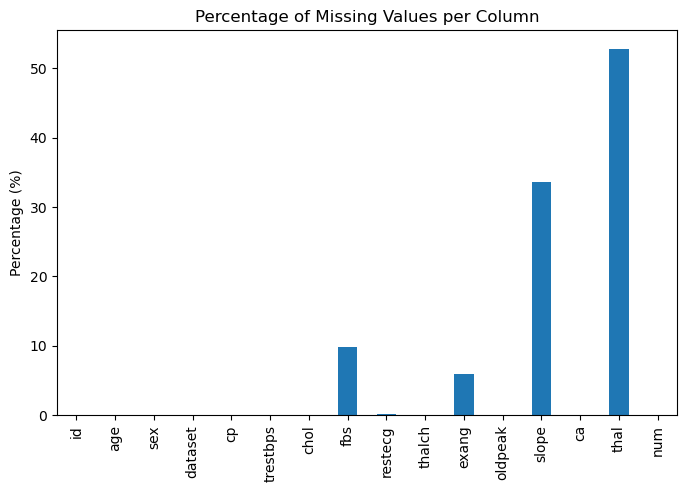

In [15]:
missing_perc = df.isna().mean()*100

missing_perc.plot(kind='bar', figsize=(8,5))
plt.title("Percentage of Missing Values per Column")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=90)
plt.show()

In [16]:
def detect_outliers_iqr(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return (series < lower) | (series > upper)
outlier_counts = {}

for col in numeric_cols:
    outlier_counts[col] = detect_outliers_iqr(df[col]).sum()

outlier_counts

{'id': np.int64(0),
 'age': np.int64(0),
 'trestbps': np.int64(28),
 'chol': np.int64(185),
 'thalch': np.int64(2),
 'oldpeak': np.int64(16),
 'ca': np.int64(128),
 'num': np.int64(0)}

In [17]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] < lower, lower,
               np.where(df[col] > upper, upper, df[col]))

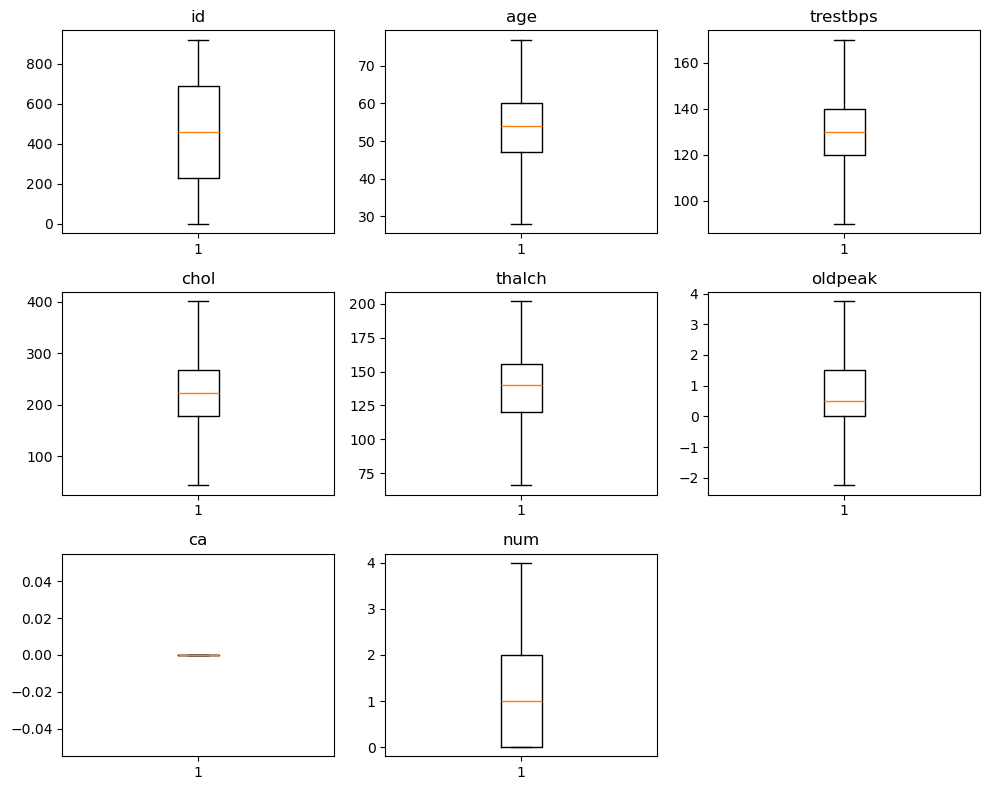

In [18]:
import math
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=np.number).columns
n = len(numeric_cols)

cols = 3
rows = math.ceil(n/cols)

plt.figure(figsize=(10,8))

for i,col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
for col in numeric_cols:

    min_val = df[col].min()
    max_val = df[col].max()

    df[col+"_norm"] = (df[col]-min_val)/(max_val-min_val)

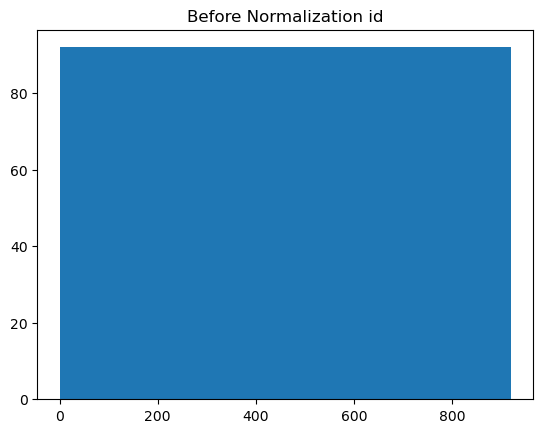

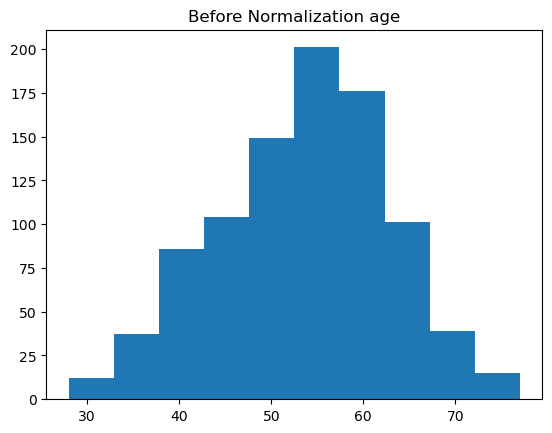

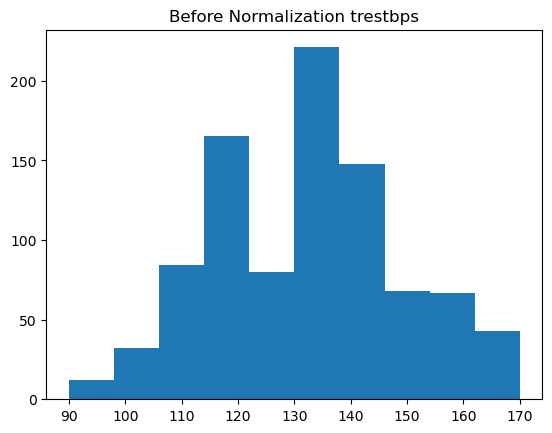

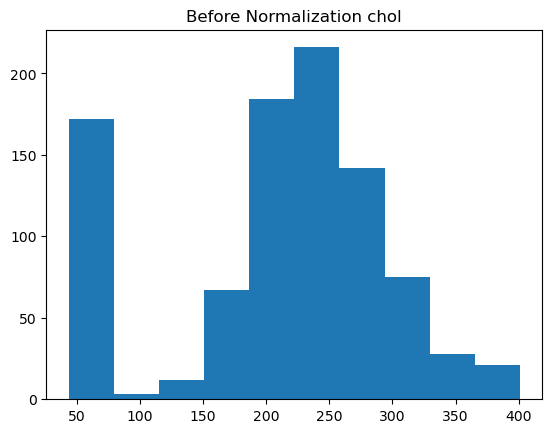

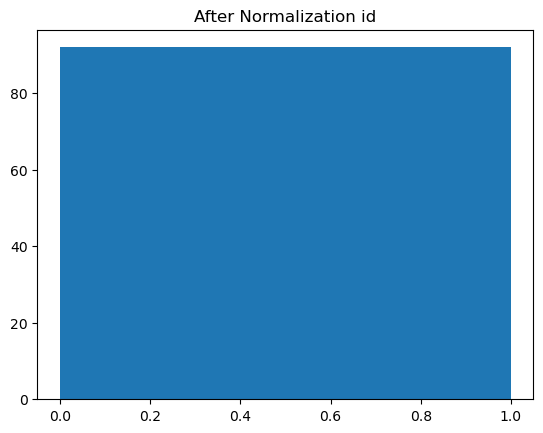

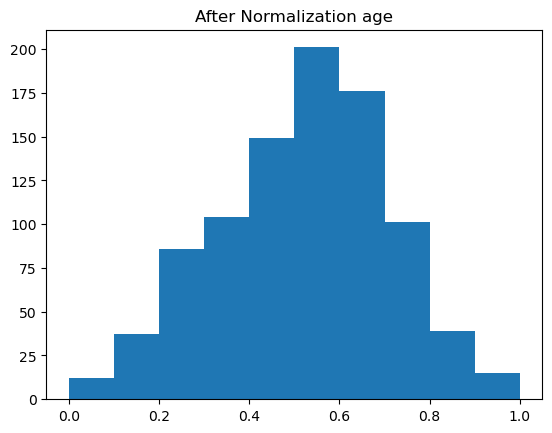

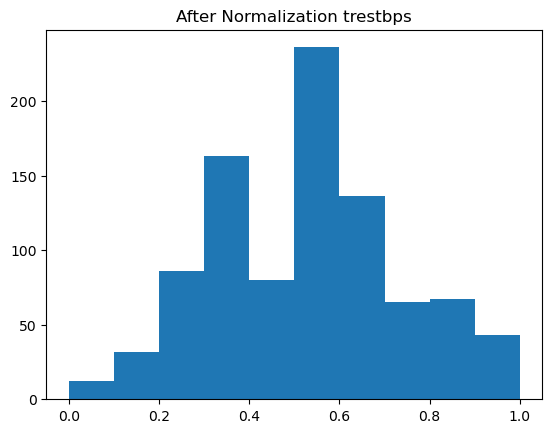

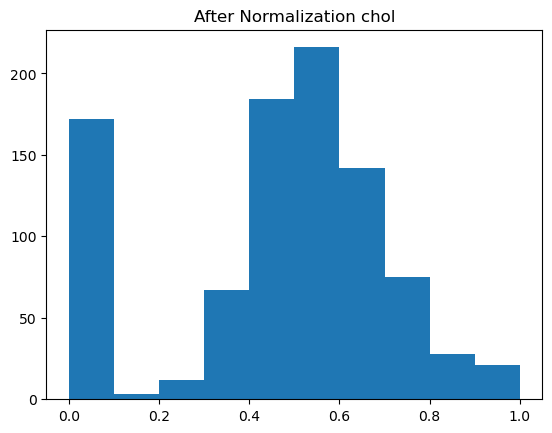

In [20]:
for col in numeric_cols[:4]:

    plt.hist(df[col])
    plt.title(f"Before Normalization {col}")
    plt.show()

for col in numeric_cols[:4]:

    plt.hist(df[col+"_norm"])
    plt.title(f"After Normalization {col}")
    plt.show()

In [21]:
dup_count = df.duplicated().sum()
print("Duplicate rows:",dup_count)

df = df.drop_duplicates()

Duplicate rows: 0


In [22]:
for col in cat_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.lower()

In [23]:
df["chol_risk_num"] = np.where(df["chol"]>240,1,0)
cp_map = {
"typical angina":1,
"atypical angina":2,
"non-anginal":3,
"asymptomatic":4
}

df["cp_severity"] = df["cp"].map(cp_map)
df["exang_num"] = df["exang"].str.lower().map({'true': 1, 'false': 0})

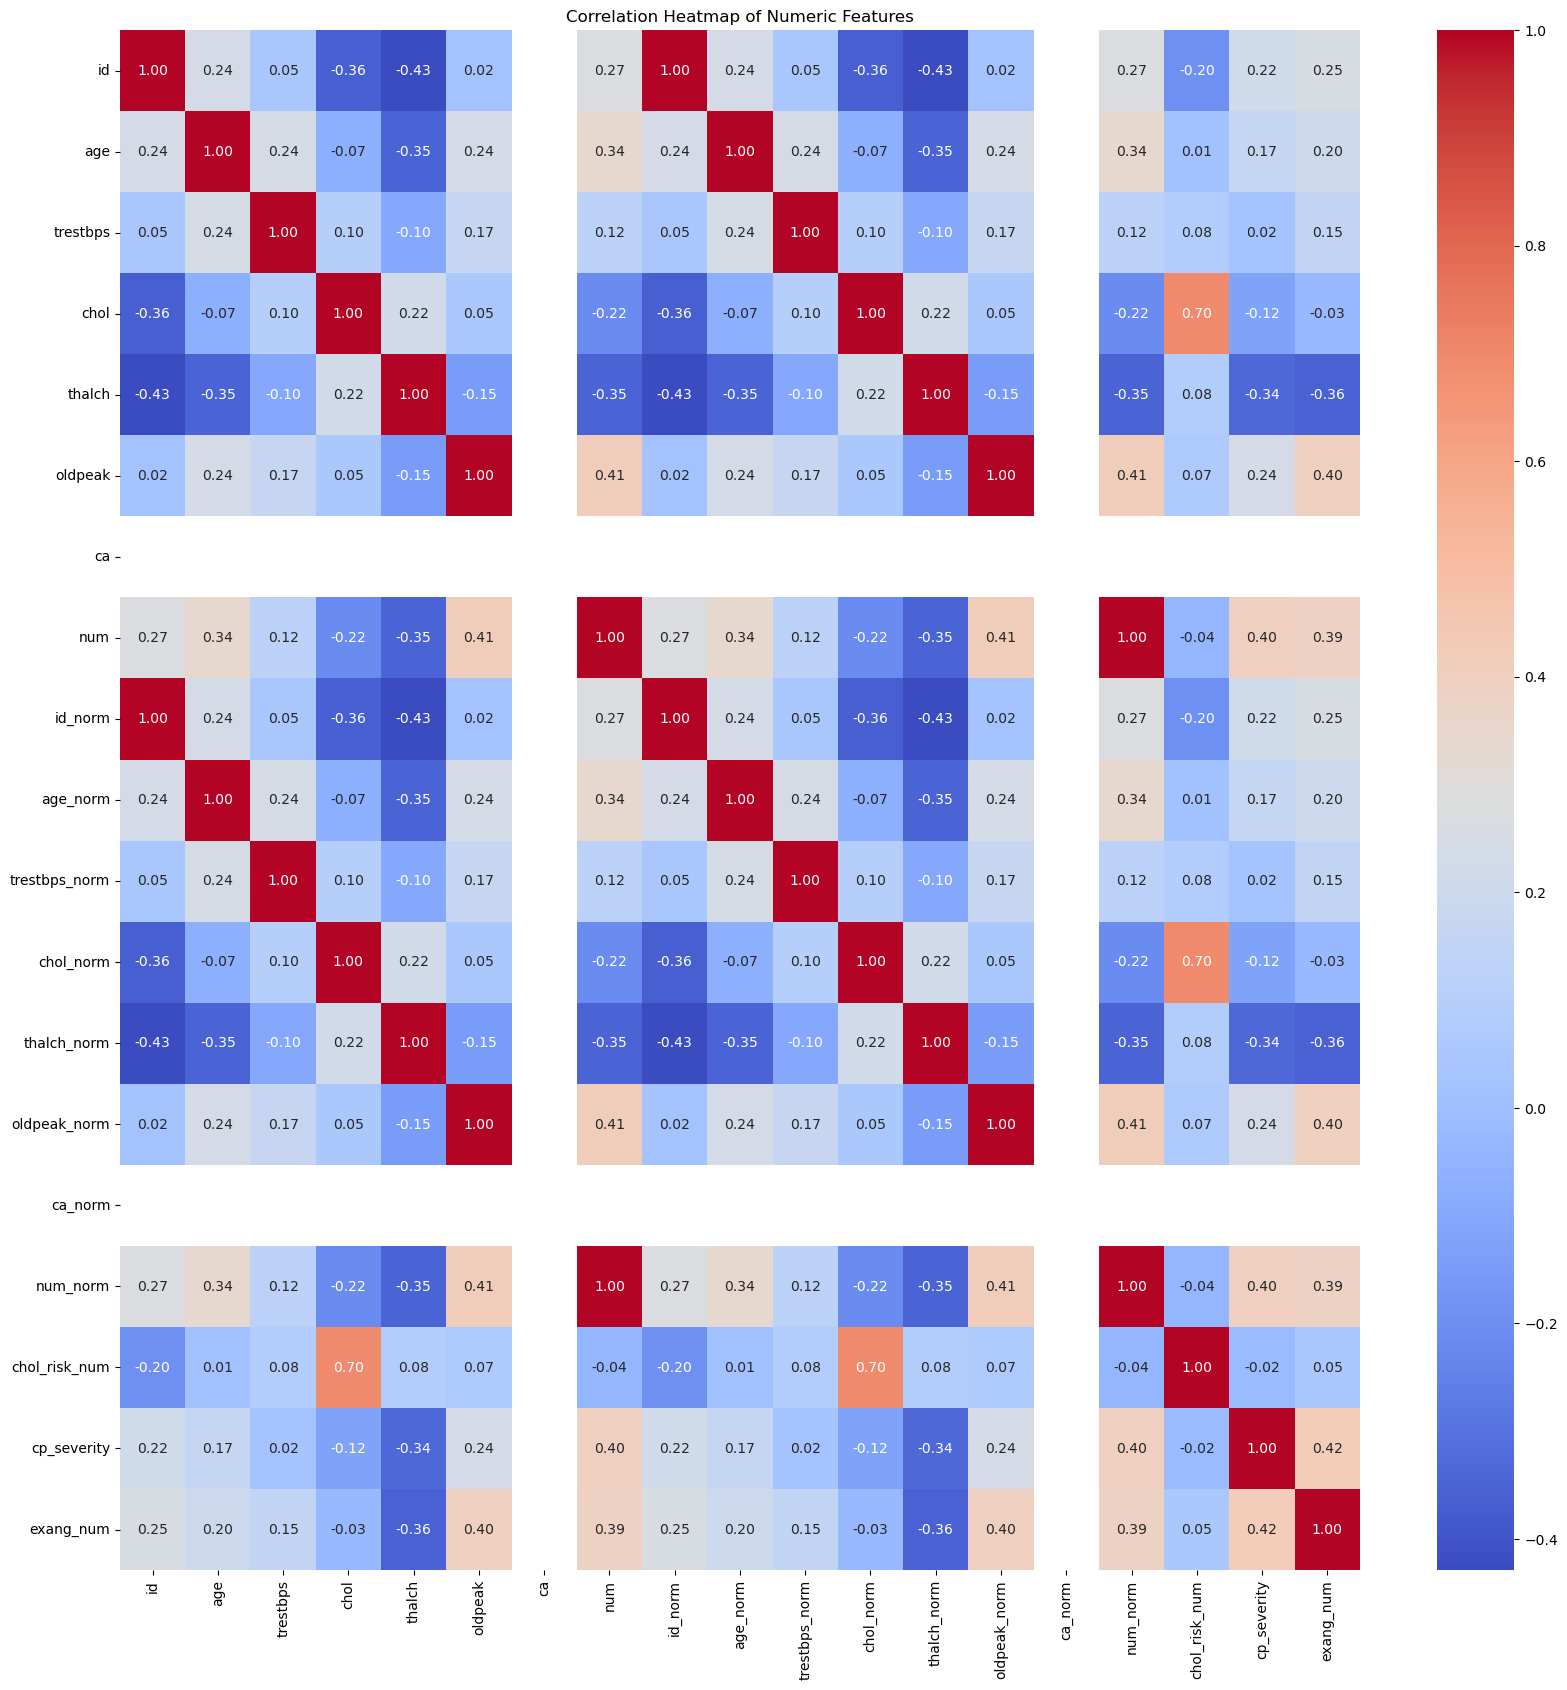

In [24]:
import seaborn as sns
numeric_data = df.select_dtypes(include=np.number)
corr_matrix = numeric_data.corr()

plt.figure(figsize=(20,20))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()